# Imports and Model initialization

In [3]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import sys
import zipfile

import numpy as np
import pandas as pd
import pydicom
from tqdm.notebook import tqdm
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_auc_score, confusion_matrix

import nibabel as nib

sys.path.insert(0, "..")
from app.ml_inference import CTScreener

model = CTScreener(tmp_dir='/home/a-lugovoi/Git/medscreen/dev/tmp')

2026-02-24 13:48:50,812 [MODEL] INFO: Загрузка модели 'google/medgemma-1.5-4b-it'...


INFO 02-24 13:48:50 [utils.py:253] non-default args: {'trust_remote_code': True, 'allowed_local_media_path': '/home/a-lugovoi/Git/medscreen/dev/tmp', 'dtype': 'bfloat16', 'seed': None, 'max_model_len': 8192, 'gpu_memory_utilization': 0.3, 'disable_log_stats': True, 'model': 'google/medgemma-1.5-4b-it'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


WARNING 02-24 13:48:51 [arg_utils.py:1175] `seed=None` is equivalent to `seed=0` in V1 Engine. You will no longer be allowed to pass `None` in v0.13.
INFO 02-24 13:48:52 [model.py:637] Resolved architecture: Gemma3ForConditionalGeneration
INFO 02-24 13:48:52 [model.py:1750] Using max model len 8192
INFO 02-24 13:48:52 [scheduler.py:228] Chunked prefill is enabled with max_num_batched_tokens=8192.
(EngineCore_DP0 pid=2071090) INFO 02-24 13:48:58 [core.py:93] Initializing a V1 LLM engine (v0.12.0) with config: model='google/medgemma-1.5-4b-it', speculative_config=None, tokenizer='google/medgemma-1.5-4b-it', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=8192, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, device_config=cuda, structured_o

(EngineCore_DP0 pid=2071090) Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


(EngineCore_DP0 pid=2071090) INFO 02-24 13:49:21 [default_loader.py:308] Loading weights took 2.77 seconds
(EngineCore_DP0 pid=2071090) INFO 02-24 13:49:22 [gpu_model_runner.py:3549] Model loading took 8.5834 GiB memory and 3.874852 seconds
(EngineCore_DP0 pid=2071090) INFO 02-24 13:49:22 [gpu_model_runner.py:4306] Encoder cache will be initialized with a budget of 8192 tokens, and profiled with 31 image items of the maximum feature size.
(EngineCore_DP0 pid=2071090) INFO 02-24 13:49:32 [backends.py:655] Using cache directory: /home/a-lugovoi/.cache/vllm/torch_compile_cache/00f8fdbe2b/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=2071090) INFO 02-24 13:49:32 [backends.py:715] Dynamo bytecode transform time: 7.98 s
(EngineCore_DP0 pid=2071090) INFO 02-24 13:49:37 [backends.py:216] Directly load the compiled graph(s) for dynamic shape from the cache, took 3.753 s
(EngineCore_DP0 pid=2071090) INFO 02-24 13:49:38 [monitor.py:34] torch.compile takes 11.74 s in total
(Engine

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|███████████████████████████████| 51/51 [00:02<00:00, 19.11it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████████████████████████████████████████████| 35/35 [00:01<00:00, 25.45it/s]


(EngineCore_DP0 pid=2071090) INFO 02-24 13:49:45 [gpu_model_runner.py:4466] Graph capturing finished in 5 secs, took 2.27 GiB
(EngineCore_DP0 pid=2071090) INFO 02-24 13:49:45 [core.py:254] init engine (profile, create kv cache, warmup model) took 23.79 seconds
INFO 02-24 13:49:49 [llm.py:343] Supported tasks: ['generate']


2026-02-24 13:49:49,092 [MODEL] INFO: Модель загружена за 58.3с


# MosMedData: Chest CT Scans with Signs of COVID-19
- https://mosmed.ai/en/datasets/datasets/covid191110/

In [6]:
archive = Path("data/mosmed/COVID19_1110.zip")
data_dir = archive.with_suffix("")  # "data/mosmed/COVID19_1110"

# 1. Extract archive to the parent directory
with zipfile.ZipFile(archive, 'r') as z:
    z.extractall(archive.parent)

# 2. Move CT-X folders up one level and remove the intermediate "studies" directory
studies_dir = data_dir / "studies"
if studies_dir.exists():
    for folder in studies_dir.iterdir():
        folder.rename(data_dir / folder.name)
    studies_dir.rmdir()

# 3. Print the resulting directory structure
print("Structure:")
for folder in sorted(d for d in data_dir.iterdir() if d.is_dir()):
    files_count = len(list(folder.glob("*.nii.gz")))
    print(f"  {folder.name}: {files_count} files")

Structure:
  CT-0: 254 files
  CT-1: 684 files
  CT-2: 125 files
  CT-3: 45 files
  CT-4: 2 files
  masks: 50 files


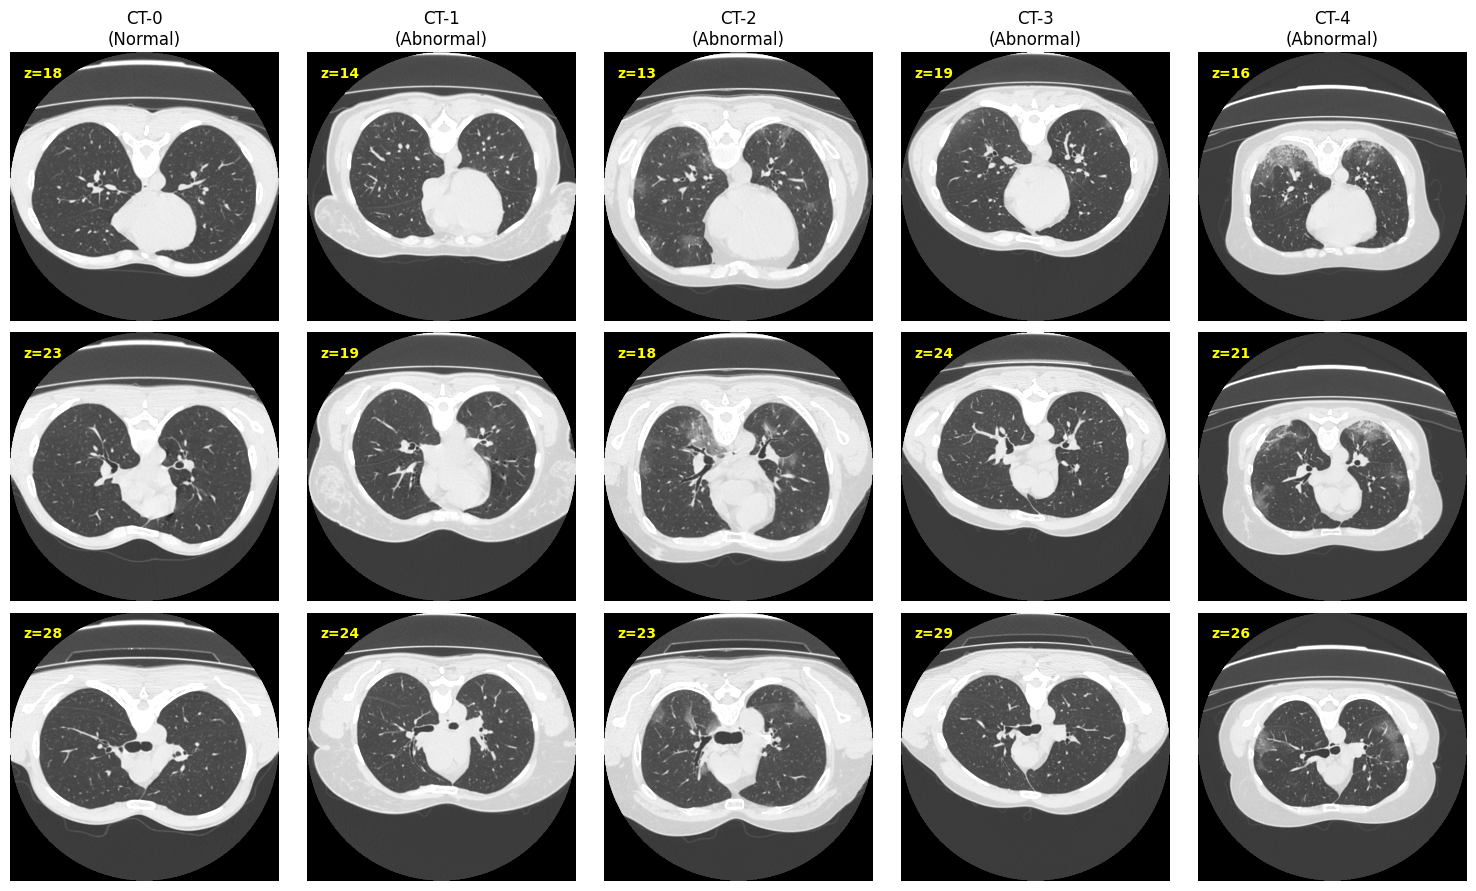

In [4]:
DATA_DIR = "data/mosmed/COVID19_1110"
groups = ["CT-0", "CT-1", "CT-2", "CT-3", "CT-4"]
n_slices = 3  # Number of slices per study
step = 5      # Step between slices (in pixels along Z axis)

fig, axes = plt.subplots(n_slices, len(groups), figsize=(15, 3 * n_slices))

for col, group in enumerate(groups):
    group_dir = os.path.join(DATA_DIR, group)
    fname = next(f for f in os.listdir(group_dir) if f.endswith(".nii.gz"))
    vol = nib.load(os.path.join(group_dir, fname)).get_fdata()
    
    z_center = vol.shape[2] // 2
    # Select n_slices around the center
    z_indices = [z_center - step, z_center, z_center + step]
    
    for row, z in enumerate(z_indices):
        ax = axes[row, col]
        slice_2d = vol[:, :, z]
        
        # Lung window: center=-600, width=1500
        ax.imshow(slice_2d.T, cmap="gray", vmin=-1350, vmax=150)
        
        # Add titles only to the top row
        if row == 0:
            ax.set_title(f"{group}\n({'Normal' if group=='CT-0' else 'Abnormal'})")
            
        ax.text(0.05, 0.95, f"z={z}", color="yellow", transform=ax.transAxes, 
                verticalalignment='top', fontsize=10, fontweight='bold')
        ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
DATA_DIR = "data/mosmed/COVID19_1110"
GROUND_TRUTH = {"CT-0": "NORMAL", "CT-1": "ABNORMAL", "CT-2": "ABNORMAL", "CT-3": "ABNORMAL", "CT-4": "ABNORMAL"}

# Gather all files first to create a single progress bar
all_studies = []
for group in sorted(GROUND_TRUTH):
    group_dir = os.path.join(DATA_DIR, group)
    if os.path.exists(group_dir):
        files = sorted([f for f in os.listdir(group_dir) if f.endswith(".nii.gz")])
        for f in files:
            all_studies.append((group, f))

rows = []
for group, fname in tqdm(all_studies, desc="Inference COVID-19"):
    path = os.path.join(DATA_DIR, group, fname)
    
    # Load and transpose NIfTI (we need shape: slices, H, W)
    volume = nib.load(path).get_fdata().astype(np.float32)
    volume = np.transpose(volume, (2, 1, 0))

    # Run inference explicitly passing windowing and other parameters
    result = model.run(
        volume, 
        center=-600, 
        width=1500,
        window_size=20,
        n_windows=5,
        threshold=0.2
    )
    
    rows.append({
        "group": group,
        "file": fname,
        "label": GROUND_TRUTH[group],
        "verdict": result["verdict"],
        "abnormal_ratio": result["abnormal_ratio"],
        "n_slices": result["total_slices"],
        "time": round(result["inference_time"], 1),
    })

df = pd.DataFrame(rows)
df.to_csv("eval_mosmed.csv", index=False)

Inference COVID-19:   0%|          | 0/1110 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


INFO 02-24 13:50:00 [chat_utils.py:574] Detected the chat template content format to be 'openai'. You can set `--chat-template-content-format` to override this.


2026-02-24 13:50:25,035 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/3 (0%) | Slices count: 60/43 (140%) | 31.1s
2026-02-24 13:50:33,687 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/3 (0%) | Slices count: 60/42 (143%) | 5.6s
2026-02-24 13:50:42,320 [MODEL] INFO: Result: ABNORMAL | ABNORMAL windows: 1/3 (33%) | Slices count: 60/41 (146%) | 5.6s
2026-02-24 13:50:51,358 [MODEL] INFO: Result: ABNORMAL | ABNORMAL windows: 1/3 (33%) | Slices count: 60/46 (130%) | 5.8s
2026-02-24 13:50:59,892 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/3 (0%) | Slices count: 60/43 (140%) | 5.6s
2026-02-24 13:51:06,997 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/2 (0%) | Slices count: 40/38 (105%) | 5.0s
2026-02-24 13:51:15,897 [MODEL] INFO: Result: ABNORMAL | ABNORMAL windows: 3/3 (100%) | Slices count: 60/44 (136%) | 5.7s
2026-02-24 13:51:22,666 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/2 (0%) | Slices count: 40/36 (111%) | 4.7s
2026-02-24 13:51:29,561 [MODEL] INFO: Result:

,Metric,Description,Value
0,Accuracy,Overall proportion of correct predictions,0.713
1,Sensitivity,Ability to correctly identify pathology (True ...,0.655
2,Specificity,Ability to correctly identify normal cases (Tr...,0.906
3,PPV (Precision),Probability that an ABNORMAL prediction is act...,0.959
4,NPV,Probability that a NORMAL prediction is actual...,0.438
5,ROC AUC,Model's ability to distinguish between classes,0.799


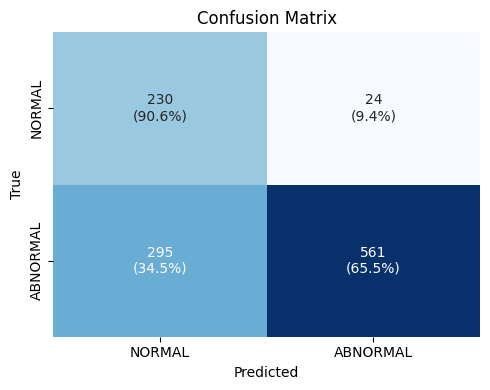


Сводка по группам (CT-0 ... CT-4):


,total,predicted_abnormal,accuracy,mean_abnormal_ratio,mean_time
group,,,,,
CT-0,254,24,0.906,0.041,5.910
CT-1,684,403,0.589,0.397,5.958
CT-2,125,113,0.904,0.659,5.928
CT-3,45,43,0.956,0.804,5.553
CT-4,2,2,1.000,1.000,5.150


In [6]:
df = pd.read_csv("eval_mosmed.csv")
y_true = (df["label"] == "ABNORMAL").astype(int)
y_pred = (df["verdict"] == "ABNORMAL").astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy", 
        "Sensitivity", 
        "Specificity", 
        "PPV (Precision)", 
        "NPV", 
        "ROC AUC"
    ],
    "Description": [
        "Overall proportion of correct predictions",
        "Ability to correctly identify pathology (True Positive Rate)",
        "Ability to correctly identify normal cases (True Negative Rate)",
        "Probability that an ABNORMAL prediction is actually pathology",
        "Probability that a NORMAL prediction is actually healthy",
        "Model's ability to distinguish between classes"
    ],
    "Value": [
        (tp + tn) / (tp + tn + fp + fn),
        tp / (tp + fn) if (tp + fn) > 0 else 0,
        tn / (tn + fp) if (tn + fp) > 0 else 0,
        tp / (tp + fp) if (tp + fp) > 0 else 0,
        tn / (tn + fn) if (tn + fn) > 0 else 0,
        roc_auc_score(y_true, df['abnormal_ratio'])
    ]
})

metrics_df["Value"] = metrics_df["Value"].round(3)
display(metrics_df)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true, y_pred)

# Считаем доли по строкам (относительно истинных классов)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Формируем подписи: "Число\n(Доля%)"
annot_labels = [[f"{val}\n({pct:.1%})" for val, pct in zip(row, pct_row)] 
                for row, pct_row in zip(cm, cm_pct)]

sns.heatmap(cm, annot=annot_labels, fmt="",
            xticklabels=["NORMAL", "ABNORMAL"], yticklabels=["NORMAL", "ABNORMAL"],
            cmap="Blues", ax=ax, cbar=False)
ax.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix")
plt.tight_layout()
plt.show()

# Добавим также разбивку по конкретным группам CT-0 .. CT-4
print("\nСводка по группам (CT-0 ... CT-4):")
summary = df.groupby("group").agg(
    total=("file", "count"),
    predicted_abnormal=("verdict", lambda x: (x == "ABNORMAL").sum()),
    accuracy=("verdict", lambda x, gt=df: (x.values == gt.loc[x.index, "label"].values).mean()),
    mean_abnormal_ratio=("abnormal_ratio", "mean"),
    mean_time=("time", "mean"),
).round(3)
display(summary)

# MosMedData LDCT with Signs of Lung Cancer (Type I)
- https://mosmed.ai/en/datasets/datasets/mm/

In [ ]:
import os, zipfile
import numpy as np
import pandas as pd
import pydicom

ARCHIVE = "data/mosmed/MosMedData-LDCT-LUNGCR.zip" # <-- путь к твоему архиву
EXTRACT_DIR = "data/mosmed/LUNGCR"

# 1. Распаковка
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ARCHIVE) as z:
    z.extractall(EXTRACT_DIR)

STUDIES_DIR = os.path.join(EXTRACT_DIR, "studies")
df_labels = pd.read_excel(os.path.join(EXTRACT_DIR, "dataset_registry.xlsx"))

# ВЫВЕДИ КОЛОНКИ: посмотри, как называется столбец с именем папки/ID и столбец с диагнозом
print("Колонки:", df_labels.columns.tolist())
display(df_labels.head())

# !!! ВНИМАНИЕ: Адаптируй названия колонок ниже под те, что вывелись выше !!!
# ID_COLUMN = "ID" 
# LABEL_COLUMN = "Diagnosis"
# df_labels["filename"] = df_labels[ID_COLUMN].astype(str)
# df_labels["gt"] = np.where(df_labels[LABEL_COLUMN] == 1, "ABNORMAL", "NORMAL")


In [ ]:
from tqdm.notebook import tqdm

def load_dicom_volume(study_dir):
    """Ищет папку с .DCM файлами, читает их, сортирует по оси Z и переводит в HU."""
    dicom_dir = None
    for root, dirs, files in os.walk(study_dir):
        if any(f.lower().endswith('.dcm') for f in files):
            dicom_dir = root
            break
            
    if not dicom_dir: return None
    
    files = [os.path.join(dicom_dir, f) for f in os.listdir(dicom_dir) if f.lower().endswith('.dcm')]
    slices = [pydicom.dcmread(f) for f in files]
    
    # Сортировка срезов по положению пациента (ось Z)
    slices.sort(key=lambda s: float(s.ImagePositionPatient[2]) if hasattr(s, 'ImagePositionPatient') else 0)
    
    img_shape = slices[0].pixel_array.shape
    volume = np.empty((len(slices), img_shape[0], img_shape[1]), dtype=np.float32)
    
    # Применяем Rescale Intercept/Slope для получения честных HU
    for i, s in enumerate(slices):
        vol = s.pixel_array.astype(np.float32)
        slope = float(getattr(s, 'RescaleSlope', 1))
        intercept = float(getattr(s, 'RescaleIntercept', 0))
        volume[i] = vol * slope + intercept
        
    return volume

rows = []

# Запускаем по всем датасетам (убедись, что df_labels['filename'] и ['gt'] заполнены верно)
for _, row in tqdm(df_labels.iterrows(), total=len(df_labels), desc="Inference"):
    study_path = os.path.join(STUDIES_DIR, str(row["filename"]))
    if not os.path.exists(study_path):
        continue
        
    volume = load_dicom_volume(study_path)
    if volume is None:
        continue
        
    r = model.run(volume)
    rows.append({"file": row["filename"], "label": row["gt"], "verdict": r["verdict"],
                  "abnormal_ratio": r["abnormal_ratio"], "n_slices": r["total_slices"],
                  "time": round(r["inference_time"], 1)})

df = pd.DataFrame(rows)
df.to


In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv("eval_lungcr.csv")
y_true = (df["label"] == "ABNORMAL").astype(int)
y_pred = (df["verdict"] == "ABNORMAL").astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Sensitivity", "Specificity", "PPV (Precision)", "NPV", "ROC AUC"],
    "Description": [
        "Overall proportion of correct predictions",
        "Ability to correctly identify pathology (True Positive Rate)",
        "Ability to correctly identify normal cases (True Negative Rate)",
        "Probability that an ABNORMAL prediction is actually pathology",
        "Probability that a NORMAL prediction is actually healthy",
        "Model's ability to distinguish between classes"
    ],
    "Value": [
        (tp + tn) / (tp + tn + fp + fn),
        tp / (tp + fn) if (tp + fn) > 0 else 0,
        tn / (tn + fp) if (tn + fp) > 0 else 0,
        tp / (tp + fp) if (tp + fp) > 0 else 0,
        tn / (tn + fn) if (tn + fn) > 0 else 0,
        roc_auc_score(y_true, df['abnormal_ratio'])
    ]
})

display(metrics_df.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_labels = [[f"{val}\n({pct:.1%})" for val, pct in zip(row, pct_row)] for row, pct_row in zip(cm, cm_pct)]

sns.heatmap(cm, annot=annot_labels, fmt="", xticklabels=["NORMAL", "ABNORMAL"], yticklabels=["NORMAL", "ABNORMAL"], cmap="Blues", ax=ax, cbar=False)
ax.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix")
plt.tight_layout()
plt.show()


# Dataset of Computed Tomography Angiography (CTA) with Signs of Calcification, Thrombosis, Dilation, and Aneurysm, Including Segmented Abdominal Aorta Lumen and Wall
- https://mosmed.ai/en/datasets/datasets/nabor-dannih-kompyuterno-tomograficheskoi-angiografii-s-priznakami-kaltsinoza-tromboza-dilatatsii-i-anevrizmi-i-soderzhaschii-segmentatsiyu-prosveta-i-stenki-bryushnogo-otdela-aorti/

In [3]:
import os, zipfile
import numpy as np
import pandas as pd
import nibabel as nib

ARCHIVE = "data/mosmed/НД_КТА_ОБП_аорта.zip"
EXTRACT_DIR = "data/mosmed/НД_КТА_ОБП_аорта"

os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ARCHIVE) as z:
    z.extractall(EXTRACT_DIR)

STUDIES_DIR = os.path.join(EXTRACT_DIR, "studies")
df_labels = pd.read_excel(os.path.join(EXTRACT_DIR, "classification.xlsx"))
df_labels.columns = ["num", "aneurysm", "diameter_mm", "calcification", "thrombosis"]
df_labels["filename"] = "orig" + df_labels["num"].astype(str) + ".nii"
df_labels["gt"] = np.where(df_labels[["aneurysm", "calcification", "thrombosis"]].any(axis=1), "ABNORMAL", "NORMAL")

print(f"Studies: {len(df_labels)} | {df_labels['gt'].value_counts().to_dict()}")

Studies: 100 | {'ABNORMAL': 61, 'NORMAL': 39}


In [4]:
from tqdm.notebook import tqdm

rows = []
for _, row in tqdm(df_labels.iterrows(), total=len(df_labels), desc="Inference"):
    path = os.path.join(STUDIES_DIR, row["filename"])
    if not os.path.exists(path):
        continue
    volume = np.transpose(nib.load(path).get_fdata().astype(np.float32), (2, 1, 0))
    r = model.run(volume)
    rows.append({"file": row["filename"], "label": row["gt"], "verdict": r["verdict"],
                  "abnormal_ratio": r["abnormal_ratio"], "n_slices": r["total_slices"],
                  "time": round(r["inference_time"], 1)})

df = pd.DataFrame(rows)
df.to_csv("eval_aorta.csv", index=False)
print(f"Done: {len(df)} studies, {df['time'].sum():.0f}s total")

Inference:   0%|          | 0/100 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


INFO 02-24 11:38:19 [chat_utils.py:574] Detected the chat template content format to be 'openai'. You can set `--chat-template-content-format` to override this.
Done: 100 studies, 1064s total


,Metric,Description,Value
0,Accuracy,Overall proportion of correct predictions,0.420
1,Sensitivity,Ability to correctly identify pathology (True ...,0.148
2,Specificity,Ability to correctly identify normal cases (Tr...,0.846
3,PPV (Precision),Probability that an ABNORMAL prediction is act...,0.600
4,NPV,Probability that a NORMAL prediction is actual...,0.388
5,ROC AUC,Model's ability to distinguish between classes,0.496


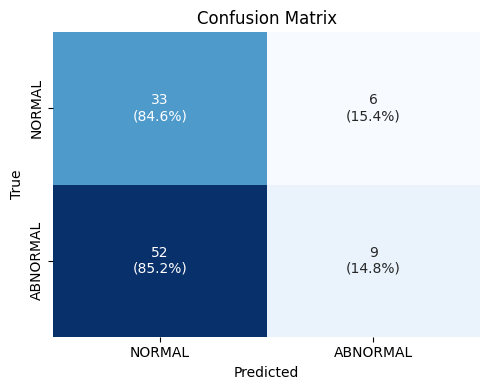

In [11]:
from sklearn.metrics import roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

df = pd.read_csv("eval_aorta.csv")
y_true = (df["label"] == "ABNORMAL").astype(int)
y_pred = (df["verdict"] == "ABNORMAL").astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy", 
        "Sensitivity", 
        "Specificity", 
        "PPV (Precision)", 
        "NPV", 
        "ROC AUC"
    ],
    "Description": [
        "Overall proportion of correct predictions",
        "Ability to correctly identify pathology (True Positive Rate)",
        "Ability to correctly identify normal cases (True Negative Rate)",
        "Probability that an ABNORMAL prediction is actually pathology",
        "Probability that a NORMAL prediction is actually healthy",
        "Model's ability to distinguish between classes"
    ],
    "Value": [
        (tp + tn) / (tp + tn + fp + fn),
        tp / (tp + fn) if (tp + fn) > 0 else 0,
        tn / (tn + fp) if (tn + fp) > 0 else 0,
        tp / (tp + fp) if (tp + fp) > 0 else 0,
        tn / (tn + fn) if (tn + fn) > 0 else 0,
        roc_auc_score(y_true, df['abnormal_ratio'])
    ]
})

metrics_df["Value"] = metrics_df["Value"].round(3)
display(metrics_df)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true, y_pred)
# Считаем доли по строкам (относительно истинных классов)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Формируем подписи: "Число\n(Доля%)"
annot_labels = [[f"{val}\n({pct:.1%})" for val, pct in zip(row, pct_row)] 
                for row, pct_row in zip(cm, cm_pct)]

sns.heatmap(cm, annot=annot_labels, fmt="",
            xticklabels=["NORMAL", "ABNORMAL"], yticklabels=["NORMAL", "ABNORMAL"],
            cmap="Blues", ax=ax, cbar=False)
ax.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix")
plt.tight_layout()
plt.show()

# RSNA Abdominal Trauma Detection PNG pt1
- https://www.kaggle.com/datasets/theoviel/rsna-abdominal-trauma-detection-png-pt1